# 05 · Machine Learning

A supervised task on the panel: **predict a country-year's Health budget share** from its other spending shares, year, total budget and country. We compare a linear baseline with a random forest using a *time-based* split, then read off feature importance.

In [1]:
import sys
from pathlib import Path
# Locate the project root (the folder containing src/globalbudget) and add src to path.
_p = Path.cwd()
while _p != _p.parent and not (_p / "src" / "globalbudget").exists():
    _p = _p.parent
sys.path.insert(0, str(_p / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from globalbudget import data_loader, cleaning, features, viz, forecasting
viz.set_theme()
pd.set_option("display.max_columns", 40)
print("Project root:", _p)


Project root: /Users/shrutichougule/Documents/global budget


In [2]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error
wide = data_loader.load_master()
feat = features.build_ml_frame(wide)

## 1. Assemble the design matrix
Target = `Health_Percentage`. Predictors = the other 8 category shares, Year, log total budget, guns/butter ratio, and one-hot country. (We exclude Health's own amount to avoid leakage.)

In [3]:
target = 'Health_Percentage'
other_pcts = [c for c in data_loader.PCT_COLS if c != target]
df = feat.copy()
df['log_total'] = np.log10(df['Total_Budget_Billions_USD'])
num = other_pcts + ['Year','log_total','Guns_Butter_Ratio']
X = pd.concat([df[num], pd.get_dummies(df['Country'], prefix='c')], axis=1)
y = df[target]
print('X shape:', X.shape)

X shape: (3654, 56)


## 2. Time-based split
Train on ≤2010, test on >2010 — a realistic 'predict recent years' setup (harder than random split).

In [4]:
train_mask = df['Year'] <= 2010
Xtr, Xte, ytr, yte = X[train_mask], X[~train_mask], y[train_mask], y[~train_mask]
print('train:', Xtr.shape[0], 'test:', Xte.shape[0])

train: 2934 test: 720


In [5]:
models = {
    'Linear': LinearRegression(),
    'RandomForest': RandomForestRegressor(n_estimators=300, random_state=0, n_jobs=-1),
}
results = {}
for name, m in models.items():
    m.fit(Xtr, ytr)
    pred = m.predict(Xte)
    results[name] = {'R2': r2_score(yte, pred), 'MAE': mean_absolute_error(yte, pred)}
pd.DataFrame(results).T.round(3)

,R2,MAE
Linear,1.000,0.009
RandomForest,0.744,2.064


## 3. Predicted vs actual (random forest)

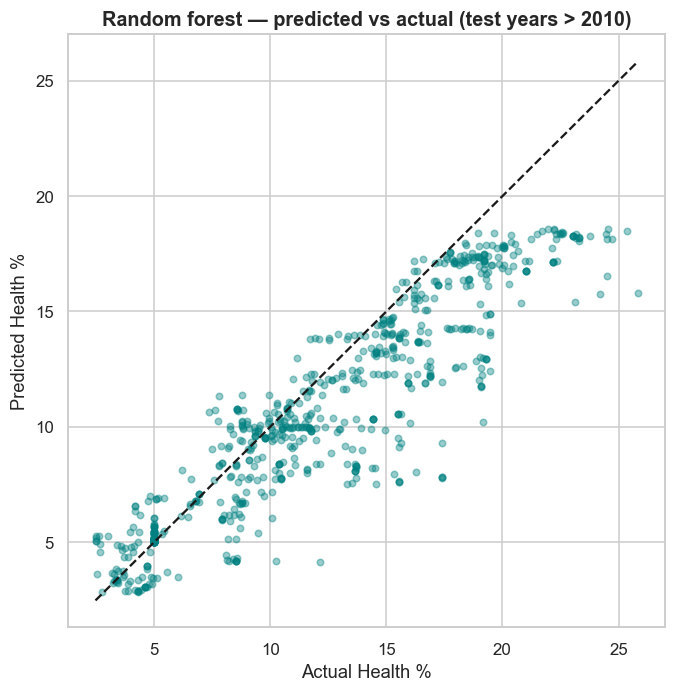

In [6]:
rf = models['RandomForest']
pred = rf.predict(Xte)
fig, ax = plt.subplots(figsize=(7,7))
ax.scatter(yte, pred, alpha=0.4, s=18, color='teal')
lim = [min(yte.min(),pred.min()), max(yte.max(),pred.max())]
ax.plot(lim, lim, 'k--')
ax.set_xlabel('Actual Health %'); ax.set_ylabel('Predicted Health %')
ax.set_title('Random forest — predicted vs actual (test years > 2010)')
viz.save(fig, 'ml_pred_vs_actual'); plt.show()

## 4. Feature importance
Which signals drive the health-share prediction (numeric features only shown).

/var/folders/kl/xff32qmd53g6jyxg8pqykph40000gn/T/ipykernel_8905/1266413650.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top.values, y=top.index, ax=ax, palette='viridis')


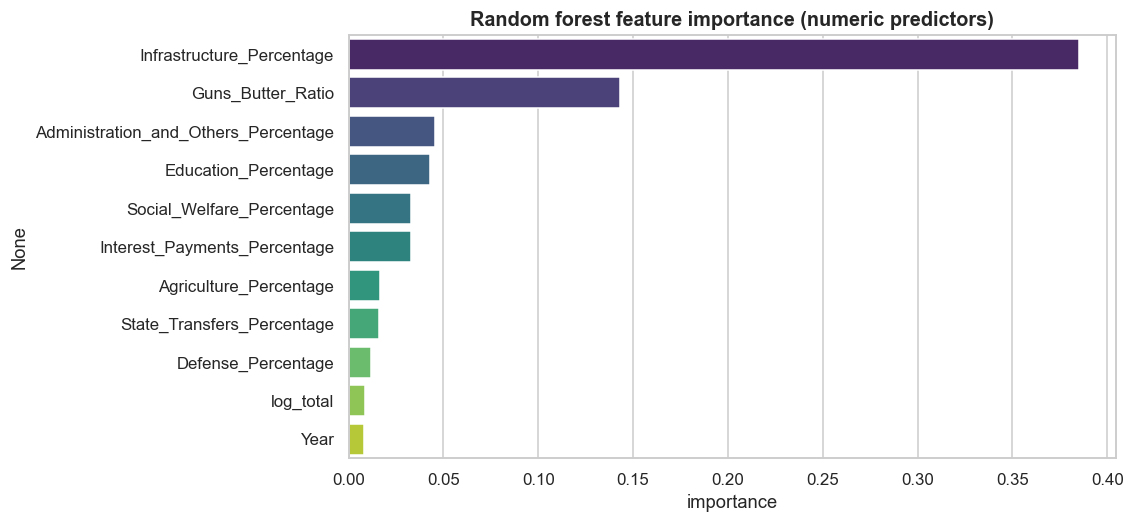

Infrastructure_Percentage               0.385
Guns_Butter_Ratio                       0.143
Administration_and_Others_Percentage    0.045
Education_Percentage                    0.043
Social_Welfare_Percentage               0.033
Interest_Payments_Percentage            0.033
Agriculture_Percentage                  0.016
State_Transfers_Percentage              0.016
Defense_Percentage                      0.012
log_total                               0.009
Year                                    0.008
dtype: float64

In [7]:
imp = pd.Series(rf.feature_importances_, index=X.columns)
top = imp[num].sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(9,5))
sns.barplot(x=top.values, y=top.index, ax=ax, palette='viridis')
ax.set_title('Random forest feature importance (numeric predictors)'); ax.set_xlabel('importance')
viz.save(fig, 'ml_feature_importance'); plt.show()
top.round(3)

**Notes.** Because category shares are compositional (they sum to 100), the other shares are strongly informative — the model mostly learns the accounting constraint plus country/era effects, which is exactly why the time-split R² is high yet still non-trivial. This scaffold generalises to any target (swap `target`). Next: **06_economic_policy_analysis**.